# **Loading The Data**

In [69]:
%pip install mlcroissant

In [70]:
# ── Standard Library ───────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import mlcroissant as mlc
warnings.filterwarnings('ignore')

# ── Sklearn: Preprocessing & Model Selection ───────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.model_selection import StratifiedKFold, cross_validate

# ── Sklearn: Models ────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# ── XGBoost ────────────────────────────────────────────────────
from xgboost import XGBClassifier

# ── Neural Network ─────────────────────────────────────────────
from sklearn.neural_network import MLPClassifier

# ── Imbalanced Learn (optional) ────────────────────────────────
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

In [71]:
# Fetch the Croissant JSON-LD
croissant_dataset = mlc.Dataset('https://www.kaggle.com/datasets/utkarshx27/american-companies-bankruptcy-prediction-dataset/croissant/download')

# Check what record sets are in the dataset
record_sets = croissant_dataset.metadata.record_sets
print(record_sets)

# Fetch the records and put them in a DataFrame
df = pd.DataFrame(croissant_dataset.records(record_set=record_sets[0].uuid))
df.head()


  -  [Metadata(US Company Bankruptcy Prediction Dataset)] Property "http://mlcommons.org/croissant/citeAs" is recommended, but does not exist.


[RecordSet(uuid="american_bankruptcy.csv")]


,american_bankruptcy.csv/company_name,american_bankruptcy.csv/status_label,american_bankruptcy.csv/year,american_bankruptcy.csv/X1,american_bankruptcy.csv/X2,american_bankruptcy.csv/X3,american_bankruptcy.csv/X4,american_bankruptcy.csv/X5,american_bankruptcy.csv/X6,american_bankruptcy.csv/X7,...,american_bankruptcy.csv/X9,american_bankruptcy.csv/X10,american_bankruptcy.csv/X11,american_bankruptcy.csv/X12,american_bankruptcy.csv/X13,american_bankruptcy.csv/X14,american_bankruptcy.csv/X15,american_bankruptcy.csv/X16,american_bankruptcy.csv/X17,american_bankruptcy.csv/X18
0,b'C_1',b'alive',1999,511.267,833.107,18.373,89.031,336.018,35.163,128.348,...,1024.333,740.998,180.447,70.658,191.226,163.816,201.026,1024.333,401.483,935.302
1,b'C_1',b'alive',2000,485.856,713.811,18.577,64.367,320.590,18.531,115.187,...,874.255,701.854,179.987,45.790,160.444,125.392,204.065,874.255,361.642,809.888
2,b'C_1',b'alive',2001,436.656,526.477,22.496,27.207,286.588,-58.939,77.528,...,638.721,710.199,217.699,4.711,112.244,150.464,139.603,638.721,399.964,611.514
3,b'C_1',b'alive',2002,396.412,496.747,27.172,30.745,259.954,-12.410,66.322,...,606.337,686.621,164.658,3.573,109.590,203.575,124.106,606.337,391.633,575.592
4,b'C_1',b'alive',2003,432.204,523.302,26.680,47.491,247.245,3.504,104.661,...,651.958,709.292,248.666,20.811,128.656,131.261,131.884,651.958,407.608,604.467


In [72]:
# remove the 'american_bankruptcy.csv/' prefix on the column names
df.columns = df.columns.str.replace('american_bankruptcy.csv/', '')
display(df.head())

,company_name,status_label,year,X1,X2,X3,X4,X5,X6,X7,...,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18
0,b'C_1',b'alive',1999,511.267,833.107,18.373,89.031,336.018,35.163,128.348,...,1024.333,740.998,180.447,70.658,191.226,163.816,201.026,1024.333,401.483,935.302
1,b'C_1',b'alive',2000,485.856,713.811,18.577,64.367,320.590,18.531,115.187,...,874.255,701.854,179.987,45.790,160.444,125.392,204.065,874.255,361.642,809.888
2,b'C_1',b'alive',2001,436.656,526.477,22.496,27.207,286.588,-58.939,77.528,...,638.721,710.199,217.699,4.711,112.244,150.464,139.603,638.721,399.964,611.514
3,b'C_1',b'alive',2002,396.412,496.747,27.172,30.745,259.954,-12.410,66.322,...,606.337,686.621,164.658,3.573,109.590,203.575,124.106,606.337,391.633,575.592
4,b'C_1',b'alive',2003,432.204,523.302,26.680,47.491,247.245,3.504,104.661,...,651.958,709.292,248.666,20.811,128.656,131.261,131.884,651.958,407.608,604.467


# **Data Description**

### **Unit of Analysis**
Each unique observation consists of a company and the corresponding reporting year.

### **Features**

- **company_name**
- **status_label -** Company Status (Target Column)
- **year**
- **X1: Current assets -** All the assets of a company that are expected to be sold or used as a result of standard business
- **X2: Cost of goods sold -** The total amount a company paid as a cost directly related to the sale of products
- **X3: Depreciation and amortization -** Depreciation refers to the loss of value of a tangible fixed asset oveR
- **X4: EBITDA -** Earnings before interest, taxes, depreciation, and amortization. A measure of a company’s overall
- **X5: Inventory -** The accounting of items and raw materials that a company either uses in production or sells
- **X6: Net Income -** The overall profitability of a company after all expenses and costs have been deducted from total revenue
- **X7: Total Receivables -** The balance of money due to a firm for goods or services delivered or used but not yet paid for
- **X8: Market Value -** The price of an asset in a marketplace. In our dataset, it refers to the market capitalization
- **X9: Net Sales -** The sum of a company’s gross sales minus its returns, allowances, and discounts
- **X10: Total Assets -** All the assets, or items of value, a business owns
- **X11: Total Long-term Debt -** A company’s loans and other liabilities that will not become due within one year of the balance
- **X12: EBIT -** Earnings before interest and taxes
- **X13: Gross Profit -** The profit a business makes after subtracting all the costs that are related to manufacturing and selling its products or services
- **X14: Total Current Liabilities -** The sum of accounts payable, accrued liabilities, and taxes such as bonds payable at the end of the year, salaries, and commissions remaining
- **X15: Retained Earnings -** The amount of profit a company has left over after paying all its direct costs, indirect costs, income taxes, and dividends to shareholders
- **X16: Total Revenue -** The amount of income that a business has made from all sales before subtracting expenses. It may include interest and dividends from investments
- **X17: Total Liabilities -** The combined debts and obligations that the company owes to outside parties
- **X18: Total Operating Expenses -** The expense a business incurs through its normal business operations

In [73]:
# rename the columns so we dont have to keep referring to the column dictionary above
column_mapping = {
    'X1': 'current_assets',
    'X2': 'cost_of_goods_sold',
    'X3': 'depreciation_amortization',
    'X4': 'ebitda',
    'X5': 'inventory',
    'X6': 'net_income',
    'X7': 'total_receivables',
    'X8': 'market_value',
    'X9': 'net_sales',
    'X10': 'total_assets',
    'X11': 'total_longterm_debt',
    'X12': 'ebit',
    'X13': 'gross_profit',
    'X14': 'total_current_liabilities',
    'X15': 'retained_earnings',
    'X16': 'total_revenue',
    'X17': 'total_liabilities',
    'X18': 'total_operating_expenses'
}

df = df.rename(columns=column_mapping)
df.head()

,company_name,status_label,year,current_assets,cost_of_goods_sold,depreciation_amortization,ebitda,inventory,net_income,total_receivables,...,net_sales,total_assets,total_longterm_debt,ebit,gross_profit,total_current_liabilities,retained_earnings,total_revenue,total_liabilities,total_operating_expenses
0,b'C_1',b'alive',1999,511.267,833.107,18.373,89.031,336.018,35.163,128.348,...,1024.333,740.998,180.447,70.658,191.226,163.816,201.026,1024.333,401.483,935.302
1,b'C_1',b'alive',2000,485.856,713.811,18.577,64.367,320.590,18.531,115.187,...,874.255,701.854,179.987,45.790,160.444,125.392,204.065,874.255,361.642,809.888
2,b'C_1',b'alive',2001,436.656,526.477,22.496,27.207,286.588,-58.939,77.528,...,638.721,710.199,217.699,4.711,112.244,150.464,139.603,638.721,399.964,611.514
3,b'C_1',b'alive',2002,396.412,496.747,27.172,30.745,259.954,-12.410,66.322,...,606.337,686.621,164.658,3.573,109.590,203.575,124.106,606.337,391.633,575.592
4,b'C_1',b'alive',2003,432.204,523.302,26.680,47.491,247.245,3.504,104.661,...,651.958,709.292,248.666,20.811,128.656,131.261,131.884,651.958,407.608,604.467


### **Checking for Missing Values**

In [74]:
# check columns for missing values - there are no missing values in any of the columns
print(df.isnull().sum())

company_name                 0
status_label                 0
year                         0
current_assets               0
cost_of_goods_sold           0
depreciation_amortization    0
ebitda                       0
inventory                    0
net_income                   0
total_receivables            0
market_value                 0
net_sales                    0
total_assets                 0
total_longterm_debt          0
ebit                         0
gross_profit                 0
total_current_liabilities    0
retained_earnings            0
total_revenue                0
total_liabilities            0
total_operating_expenses     0
dtype: int64


### **Checking for Extreme Values**

In [75]:
# check columns for extreme values
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,78682.0,2007.506317,5.742768,1999.0000,2002.00000,2007.00000,2012.00000,2018.00
current_assets,78682.0,880.362485,3928.564794,-7.7600,18.92400,100.44950,431.52675,169662.00
cost_of_goods_sold,78682.0,1594.529029,8930.484664,-366.6450,17.03825,103.66100,634.54800,374623.00
depreciation_amortization,78682.0,121.234256,652.376804,0.0000,1.19200,7.92950,47.97175,28430.00
ebitda,78682.0,376.759424,2012.023142,-21913.0000,-0.81100,15.03450,139.65525,81730.00
inventory,78682.0,201.605717,1060.766096,0.0000,0.00000,7.02300,74.74725,62567.00
net_income,78682.0,129.382453,1265.532022,-98696.0000,-7.41575,1.61600,40.14425,104821.00
total_receivables,78682.0,286.832743,1335.978571,-0.0060,3.28125,22.82000,131.58050,65812.00
market_value,78682.0,3414.354610,18414.103647,0.0001,34.98000,227.51185,1244.88995,1073390.54
net_sales,78682.0,2364.019706,11950.068842,-1964.9990,27.54850,186.59850,1046.40250,511729.00


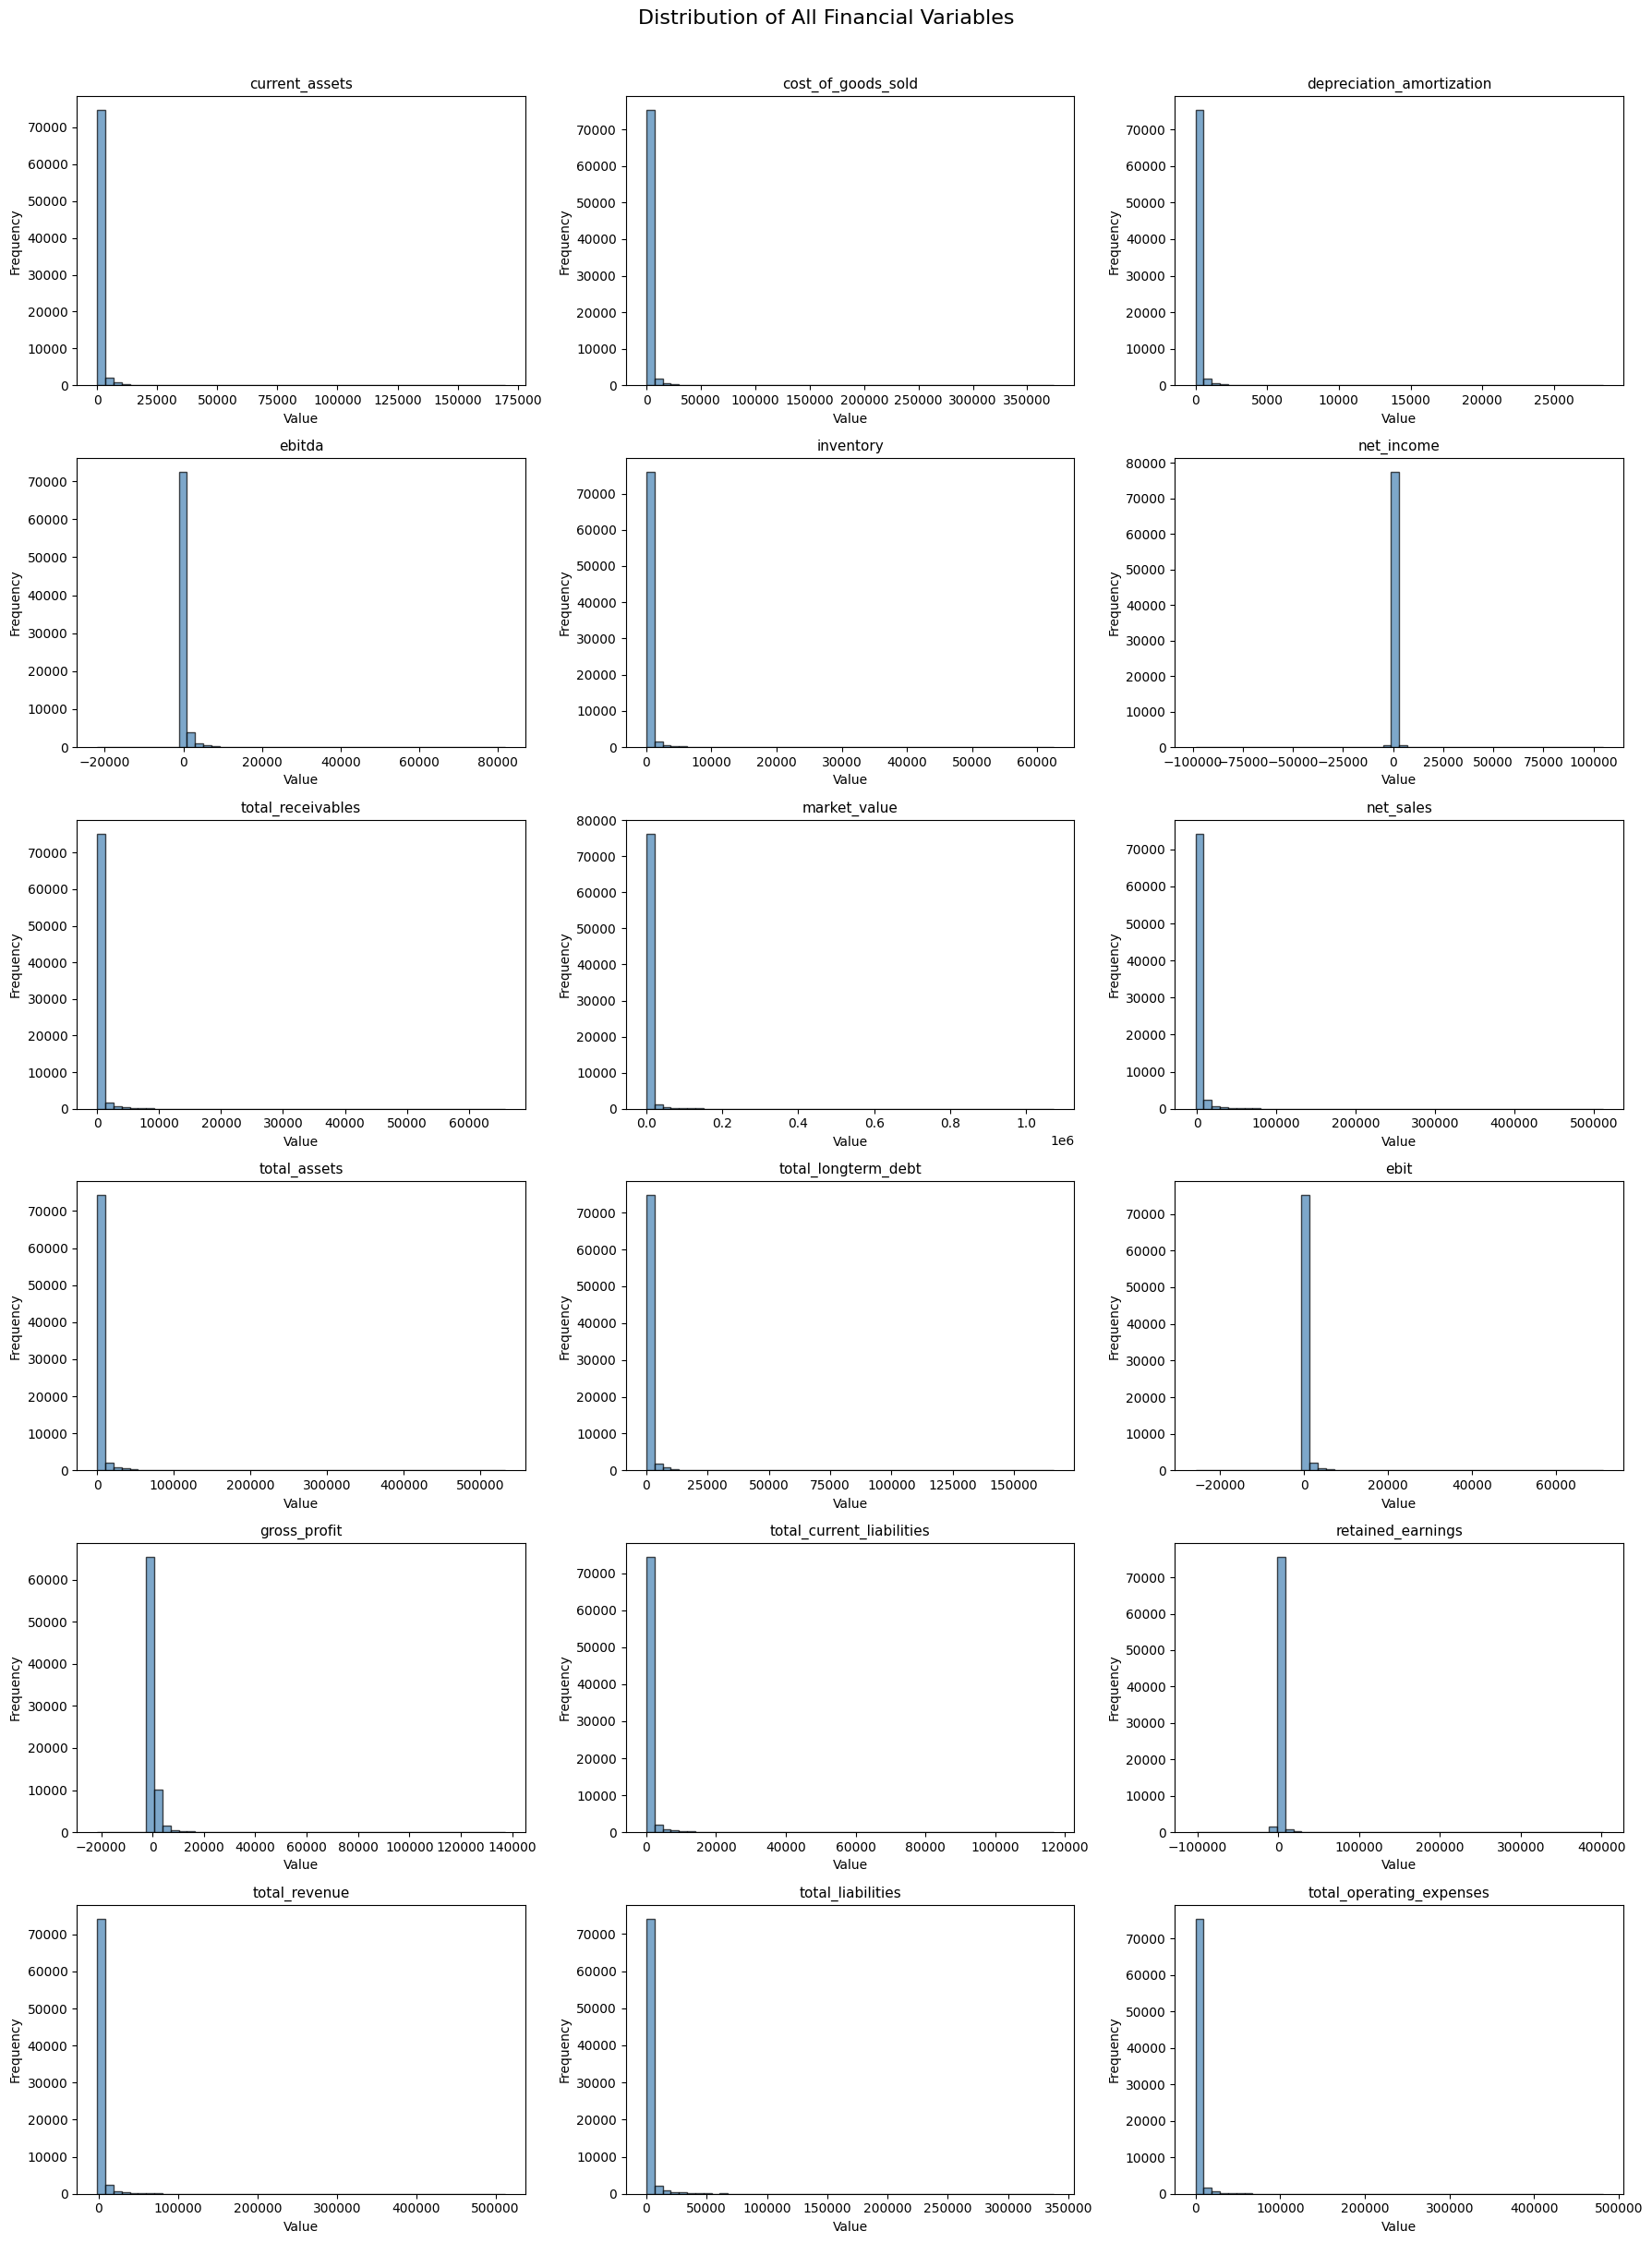

In [76]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

numeric_cols = df.select_dtypes(include='number').drop(columns=['year'])

fig, axes = plt.subplots(6, 3, figsize=(18, 24))
axes = axes.flatten()

for i, col in enumerate(numeric_cols.columns):
    axes[i].hist(df[col], bins=50, edgecolor='black', color='steelblue', alpha=0.7)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

plt.suptitle('Distribution of All Financial Variables', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

### **Checking Other Data Features**

In [77]:
# 1. Firm-year observations
print("=== FIRM-YEAR OBSERVATIONS ===")
print("Total firm-year obs:", len(df))
print("Unique firms:", df['company_name'].nunique())
print("Year range:", df['year'].min(), "to", df['year'].max())
print("Unique years:", df['year'].nunique())

# 2. Bankrupt observations
print("\n=== BANKRUPTCY COUNTS ===")
print(df['status_label'].value_counts())
print(df['status_label'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

# 3. Bankruptcy rate by sample period
print("\n=== BANKRUPTCY RATE BY PERIOD ===")
def get_period(year):
    if year <= 2011:
        return 'Train (1999-2011)'
    elif year <= 2014:
        return 'Validation (2012-2014)'
    else:
        return 'Test (2015-2018)'

df['period'] = df['year'].apply(get_period)
period_stats = df.groupby('period')['status_label'].apply(
    lambda x: f"{(x == b'failed').sum() / len(x) * 100:.2f}%"
)
print(period_stats)

=== FIRM-YEAR OBSERVATIONS ===
Total firm-year obs: 78682
Unique firms: 8971
Year range: 1999 to 2018
Unique years: 20

=== BANKRUPTCY COUNTS ===
status_label
b'alive'     73462
b'failed'     5220
Name: count, dtype: int64
status_label
b'alive'     93.37%
b'failed'     6.63%
Name: proportion, dtype: object

=== BANKRUPTCY RATE BY PERIOD ===
period
Test (2015-2018)          2.34%
Train (1999-2011)         7.94%
Validation (2012-2014)    4.69%
Name: status_label, dtype: object


# **Feature Engineering**

In [79]:
# Avoid division by zero by replacing 0s with NaN
df['current_ratio'] = df['current_assets'] / df['total_current_liabilities'].replace(0, float('nan'))
df['working_capital_to_assets'] = (df['current_assets'] - df['total_current_liabilities']) / df['total_assets'].replace(0, float('nan'))

# Profitability
df['roa'] = df['net_income'] / df['total_assets'].replace(0, float('nan'))
df['ebitda_margin'] = df['ebitda'] / df['total_revenue'].replace(0, float('nan'))
df['gross_margin'] = df['gross_profit'] / df['total_revenue'].replace(0, float('nan'))
df['ebit_margin'] = df['ebit'] / df['total_revenue'].replace(0, float('nan'))
df['retained_earnings_to_assets'] = df['retained_earnings'] / df['total_assets'].replace(0, float('nan'))

# Leverage
df['debt_ratio'] = df['total_liabilities'] / df['total_assets'].replace(0, float('nan'))
df['longterm_debt_to_assets'] = df['total_longterm_debt'] / df['total_assets'].replace(0, float('nan'))
df['debt_to_equity'] = df['total_liabilities'] / (df['total_assets'] - df['total_liabilities']).replace(0, float('nan'))

# Efficiency
df['asset_turnover'] = df['net_sales'] / df['total_assets'].replace(0, float('nan'))
df['inventory_turnover'] = df['cost_of_goods_sold'] / df['inventory'].replace(0, float('nan'))
df['receivables_turnover'] = df['net_sales'] / df['total_receivables'].replace(0, float('nan'))

# Market-based
df['market_to_liabilities'] = df['market_value'] / df['total_liabilities'].replace(0, float('nan'))
df['market_to_assets'] = df['market_value'] / df['total_assets'].replace(0, float('nan'))

print("New columns added:", df.shape[1], "total columns")
df.head()

New columns added: 37 total columns


,company_name,status_label,year,current_assets,cost_of_goods_sold,depreciation_amortization,ebitda,inventory,net_income,total_receivables,...,ebit_margin,retained_earnings_to_assets,debt_ratio,longterm_debt_to_assets,debt_to_equity,asset_turnover,inventory_turnover,receivables_turnover,market_to_liabilities,market_to_assets
0,b'C_1',b'alive',1999,511.267,833.107,18.373,89.031,336.018,35.163,128.348,...,0.068980,0.271291,0.541814,0.243519,1.182519,1.382369,2.479352,7.980903,0.928438,0.503040
1,b'C_1',b'alive',2000,485.856,713.811,18.577,64.367,320.590,18.531,115.187,...,0.052376,0.290751,0.515267,0.256445,1.062990,1.245637,2.226554,7.589876,1.042794,0.537317
2,b'C_1',b'alive',2001,436.656,526.477,22.496,27.207,286.588,-58.939,77.528,...,0.007376,0.196569,0.563172,0.306532,1.289229,0.899355,1.837052,8.238585,0.911564,0.513367
3,b'C_1',b'alive',2002,396.412,496.747,27.172,30.745,259.954,-12.410,66.322,...,0.005893,0.180749,0.570377,0.239809,1.327623,0.883074,1.910903,9.142321,0.365979,0.208746
4,b'C_1',b'alive',2003,432.204,523.302,26.680,47.491,247.245,3.504,104.661,...,0.031921,0.185938,0.574669,0.350583,1.351109,0.919167,2.116532,6.229235,0.757853,0.435515


In [80]:
new_ratio_cols = ['current_ratio', 'working_capital_to_assets', 'roa', 'ebitda_margin',
                  'gross_margin', 'ebit_margin', 'retained_earnings_to_assets', 'debt_ratio',
                  'longterm_debt_to_assets', 'debt_to_equity', 'asset_turnover',
                  'inventory_turnover', 'receivables_turnover', 'market_to_liabilities', 'market_to_assets']

print(df[new_ratio_cols].isnull().sum())

current_ratio                      0
working_capital_to_assets          0
roa                                0
ebitda_margin                      0
gross_margin                       0
ebit_margin                        0
retained_earnings_to_assets        0
debt_ratio                         0
longterm_debt_to_assets            0
debt_to_equity                     2
asset_turnover                     0
inventory_turnover             19701
receivables_turnover            2205
market_to_liabilities              0
market_to_assets                   0
dtype: int64


In [81]:
# we can either fill the null columns with 0 or median values - for now we fill with median values to avoid distortion
for col in new_ratio_cols:
    df[col] = df[col].fillna(df[col].median())

# **Modeling**

### **Altman**